In [1]:
# Cell 1: Initialize notebook configuration (autoreload modules and inline plotting).
# Order of execution: 1
# --------------------------------------------------
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Cell 2: 
# Order of execution: 2
# --------------------------------------------------
import os
import sys
import time
import random
import logging
import warnings

import numpy as np
import pandas as pd
import torch
import lightning.pytorch as pl
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import NeuralForecastModel

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

print("Darts:", __import__("darts").__version__)
print("NeuralForecast:", __import__("neuralforecast").__version__)
print("Torch:", torch.__version__)

Darts: 0.46.1
NeuralForecast: 3.2.1
Torch: 2.8.0+cu129


In [3]:
# Cell 3: Set deterministic seeds across numpy, random, and PyTorch for reproducibility.
# Order of execution: 3
# --------------------------------------------------
# ============================================================
# DETERMINISTIC SEED SETTING
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True, warn_only=True)

pl.seed_everything(SEED, workers=True)

print("Seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed set to: 42
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
# Cell 4: Configure environment path to include the local 'engression-ts' library.
# Order of execution: 4
# --------------------------------------------------
# ============================================================
# ENGRESSION-TS REPOSITORY
# ============================================================

repo_path = r"C:\Users\Anusha\engression\engression-ts"

if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print("Repository exists:", os.path.exists(repo_path))
print(
    "engressionts exists:",
    os.path.exists(os.path.join(repo_path, "engressionts"))
)

Repository exists: True
engressionts exists: True


In [5]:
# Cell 5: Import the core EnPatchTST model class for the NeuralForecast backbone.
# Order of execution: 5
# --------------------------------------------------
# ============================================================
# MODEL IMPORT
# ============================================================

# Change ONLY this import when testing another NF + Engression model.

from engressionts.models.neuralforecast.enbitcn import EnBiTCN

In [6]:
# Cell 6: Define target, windowing, and architectural hyperparameters for the experiment.
# Order of execution: 6
# --------------------------------------------------
# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================

INPUT_CHUNK_LENGTH = 24
OUTPUT_CHUNK_LENGTH = 24

BATCH_SIZE = 64

# Engression training samples used by Energy Score
NUM_SAMPLES_TRAIN = 2

NOISE_STD = 1.0
NOISE_TYPE = "uniform"

LEARNING_RATE = 1e-3

# TRAINING BUDGET

# For the current SANITY TEST:
# We want approximately 1 epoch worth of optimizer steps.
#
# For the FINAL experiment:
# set TRAINING_EPOCHS = 30.
#
# max_steps is NOT 
#  * epochs.
# We first estimate the number of optimizer steps per epoch
# from the number of available NF training windows.

TRAINING_EPOCHS = 1

# Final experiment:
# TRAINING_EPOCHS = 30

NUM_SAMPLES_PRED = 100

print("Input length :", INPUT_CHUNK_LENGTH)
print("Forecast horizon:", OUTPUT_CHUNK_LENGTH)
print("Batch size:", BATCH_SIZE)
print("Training epochs:", TRAINING_EPOCHS)
print("Prediction samples:", NUM_SAMPLES_PRED)

Input length : 24
Forecast horizon: 24
Batch size: 64
Training epochs: 1
Prediction samples: 100


In [7]:
# Cell 7: Load the raw Solar NIPS dataset from the GluonTS repository.
# Order of execution: 7
# --------------------------------------------------
# ============================================================
# SOLAR NIPS DATASET
# ============================================================

from gluonts.dataset.repository.datasets import get_dataset
from gluonts.dataset.multivariate_grouper import MultivariateGrouper

DATASET_NAME = "solar_nips"

ds = get_dataset(
    DATASET_NAME,
    regenerate=False
)

freq = ds.metadata.freq

train_list = list(ds.train)
test_list = list(ds.test)

num_test_dates = len(test_list) // len(train_list)

target_dim = int(
    ds.metadata.feat_static_cat[0].cardinality
)

print("Dataset:", DATASET_NAME)
print("Number of series:", len(train_list))
print("Target dimensions:", target_dim)
print("Number of test windows:", num_test_dates)
print("Frequency:", freq)

Dataset: solar_nips
Number of series: 137
Target dimensions: 137
Number of test windows: 7
Frequency: h


In [8]:
# Cell 8: Helper function to convert multivariate GluonTS datasets into Darts TimeSeries objects.
# Order of execution: 8
# --------------------------------------------------
# ============================================================
# GLUONTS → DARTS MULTIVARIATE TIMESERIES
# ============================================================

def gluonts_item_to_darts_mv(item, freq: str) -> TimeSeries:

    start = (
        item["start"].to_timestamp()
        if hasattr(item["start"], "to_timestamp")
        else pd.Timestamp(item["start"])
    )

    target = np.asarray(item["target"])

    if target.ndim != 2:
        raise ValueError(
            f"Expected multivariate target with ndim=2, "
            f"got shape {target.shape}"
        )

    # GluonTS: (D, T)
    # Darts:   (T, D)
    values = target.T

    times = pd.date_range(
        start=start,
        periods=values.shape[0],
        freq=freq
    )

    cols = [
        f"dim_{i}"
        for i in range(values.shape[1])
    ]

    return TimeSeries.from_times_and_values(
        times,
        values,
        columns=cols
    )

In [9]:
# Cell 9: Helper function to convert multivariate GluonTS datasets into Darts TimeSeries objects.
# Order of execution: 9
# --------------------------------------------------
# ============================================================
# GROUP SOLAR SERIES
# ============================================================

train_grouper = MultivariateGrouper(
    max_target_dim=target_dim
)

test_grouper = MultivariateGrouper(
    num_test_dates=num_test_dates,
    max_target_dim=target_dim
)

train_mv_items = list(
    train_grouper(train_list)
)

test_mv_items = list(
    test_grouper(test_list)
)

train_ts = gluonts_item_to_darts_mv(
    train_mv_items[0],
    freq
)

test_ts_list = [
    gluonts_item_to_darts_mv(item, freq)
    for item in test_mv_items
]

print("Training shape:", train_ts.shape)
print("Number of test windows:", len(test_ts_list))

Training shape: (7009, 137, 1)
Number of test windows: 7


In [10]:
# Cell 10: Normalize target time series using MinMaxScaler to the range [0, 1].
# Order of execution: 10
# --------------------------------------------------
# ============================================================
# SCALE TARGET
# ============================================================

y_scaler = Scaler()

train_y_sc = y_scaler.fit_transform(
    train_ts
).astype("float32")

print("Scaled training shape:", train_y_sc.shape)

Scaled training shape: (7009, 137, 1)


In [11]:
# Cell 11: Document configuration parameters and why covariates are omitted.
# Order of execution: 11
# --------------------------------------------------
# ============================================================
# COVARIATES
# ============================================================

# EnPatchTST currently declares:
#
# EXOGENOUS_FUTR = False
# EXOGENOUS_HIST = False
# EXOGENOUS_STAT = False
# EXOGENOUS_CAT  = False
#
# Therefore we do NOT pass past_covariates or future_covariates
# to the EnPatchTST experiment.
#
# The Solar target processing/scaling remains the same as the
# Darts experiment, but covariates are omitted because this
# NF model currently does not support them.

In [12]:
# Cell 12: Construct the 7 standard Solar NIPS test windows for forecast evaluation.
# Order of execution: 12
# --------------------------------------------------
# ============================================================
# CREATE 7 SOLAR TEST WINDOWS
# ============================================================

def get_test_windows(dataset, num_nodes=137):

    all_series = []

    for entry in dataset:

        idx = pd.date_range(
            start=entry["start"].to_timestamp(),
            periods=len(entry["target"]),
            freq=entry["start"].freqstr
        )

        all_series.append(
            pd.Series(
                entry["target"],
                index=idx
            )
        )

    # Solar NIPS ordering:
    # Node0_W1 ... Node136_W1
    # Node0_W2 ... Node136_W2
    # ...

    num_windows = len(all_series) // num_nodes

    windows = []

    for w in range(num_windows):

        start_idx = w * num_nodes
        end_idx = (w + 1) * num_nodes

        window_df = pd.concat(
            all_series[start_idx:end_idx],
            axis=1
        )

        window_df.columns = [
            f"node_{i}"
            for i in range(num_nodes)
        ]

        windows.append(window_df)

    return windows


test_windows = get_test_windows(
    ds.test,
    num_nodes=target_dim
)

print("Number of test windows:", len(test_windows))

for i, window in enumerate(test_windows):

    print(
        f"Window {i+1}:",
        window.shape,
        window.index[0],
        "→",
        window.index[-1]
    )

Number of test windows: 7
Window 1: (7033, 137) 2006-01-01 00:00:00 → 2006-10-21 00:00:00
Window 2: (7057, 137) 2006-01-01 00:00:00 → 2006-10-22 00:00:00
Window 3: (7081, 137) 2006-01-01 00:00:00 → 2006-10-23 00:00:00
Window 4: (7105, 137) 2006-01-01 00:00:00 → 2006-10-24 00:00:00
Window 5: (7129, 137) 2006-01-01 00:00:00 → 2006-10-25 00:00:00
Window 6: (7153, 137) 2006-01-01 00:00:00 → 2006-10-26 00:00:00
Window 7: (7177, 137) 2006-01-01 00:00:00 → 2006-10-27 00:00:00


In [13]:
# Cell 13: Estimate training budget (number of optimization steps corresponding to an epoch).
# Order of execution: 13
# --------------------------------------------------
# ============================================================
# ESTIMATE NF TRAINING STEPS PER EPOCH
# ============================================================

# NF uses:
#   batch_size = number of different series in a batch
#   windows_batch_size = number of windows sampled in a training batch
#
# For our experiment, we explicitly define the effective
# number of training windows and use it to estimate the
# number of optimizer steps corresponding to one epoch.
#
# input_size = 24
# horizon    = 24
# step_size  = 1

INPUT_SIZE = INPUT_CHUNK_LENGTH
HORIZON = OUTPUT_CHUNK_LENGTH
STEP_SIZE = 1

# Number of possible rolling windows per Solar series.
windows_per_series = max(
    0,
    1 + (train_ts.n_timesteps - INPUT_SIZE - HORIZON) // STEP_SIZE
)

# Solar has 137 series.
total_training_windows = (
    target_dim * windows_per_series
)

# NF PatchTST default / our chosen window batch size.
WINDOWS_BATCH_SIZE = 1024

steps_per_epoch = int(
    np.ceil(
        total_training_windows / WINDOWS_BATCH_SIZE
    )
)

print("Training timesteps:", train_ts.n_timesteps)
print("Windows per series:", windows_per_series)
print("Total training windows:", total_training_windows)
print("Windows batch size:", WINDOWS_BATCH_SIZE)
print("Estimated steps per epoch:", steps_per_epoch)

Training timesteps: 7009
Windows per series: 6962
Total training windows: 953794
Windows batch size: 1024
Estimated steps per epoch: 932


In [14]:
# Cell 14: Define training limit variable (max_steps) for sanity checking and final training.
# Order of execution: 14
# --------------------------------------------------
# ============================================================
# MAX STEPS — SANITY TEST
# ============================================================

# For this sanity test, we intentionally train for only
# ONE optimizer/training step.

MAX_STEPS = 109

print("Sanity test:")
print("Using max_steps:", MAX_STEPS)

Sanity test:
Using max_steps: 109


In [15]:
# Cell 15: Import the custom Engression PL Module and Darts Wrapper adapter.
# Order of execution: 15
# --------------------------------------------------
# Import the custom Engression adapter from the engressionts package
from engressionts.models.darts.en_nf_model import EngressionNeuralForecastModel


In [16]:
# Cell 16: Instantiate the model using the custom Darts wrapper and set max_steps in pl_trainer_kwargs.
# Order of execution: 16
# --------------------------------------------------
# ============================================================
# CREATE NF + ENGRESSION MODEL
# ============================================================

from pytorch_lightning.callbacks import Callback

class StepTrackerCallback(Callback):
    def __init__(self):
        self.step_count = 0
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        self.step_count += 1

tracker = StepTrackerCallback()

model = EngressionNeuralForecastModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    model=EnBiTCN,
    batch_size=BATCH_SIZE,
    model_kwargs={
        "num_samples_train": NUM_SAMPLES_TRAIN,
        "noise_std": NOISE_STD,
        "noise_type": NOISE_TYPE,
    },
    random_state=SEED,
    optimizer_kwargs={
        "lr": LEARNING_RATE,
    },
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": [0],
        "max_steps": MAX_STEPS,
        "callbacks": [tracker],
    },
)

print("Model created:", type(model).__name__)

Model created: EngressionNeuralForecastModel


In [17]:
import torch

print(torch.cuda.get_device_name(0))
print(f"Total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total: 6.00 GB
Allocated: 0.00 GB
Reserved: 0.00 GB


In [18]:
# Cell 17: Train the model on the normalized target data using the custom trainer.
# Order of execution: 17
# --------------------------------------------------
# ============================================================
# TRAIN
# ============================================================

start_time = time.time()

model.fit(
    series=train_y_sc,
    verbose=True,
)

training_time = time.time() - start_time

print(
    f"Training time: {training_time:.2f} seconds"
)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Training time: 10.06 seconds


In [37]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

Allocated: 0.00 GB
Reserved:  0.00 GB


In [38]:
# Cell 18: Perform probabilistic predictions on the training data as a sanity check.
# Order of execution: 18
# --------------------------------------------------
# ============================================================
# BASIC PROBABILISTIC PREDICTION SANITY TEST
# ============================================================

forecast = model.predict(
    n=OUTPUT_CHUNK_LENGTH,
    series=train_y_sc,
    num_samples=NUM_SAMPLES_PRED,
    verbose=False,
)

print("Forecast shape:", forecast.shape)
print(
    "Raw values shape:",
    forecast.all_values().shape
)

print("========== PREDICTION TIME DEBUG ==========")

print("Input series:")
print("  start:", train_y_sc.start_time())
print("  end:  ", train_y_sc.end_time())
print("  length:", len(train_y_sc))

print("\nPast covariates:")
print("  Omitted (not supported by EnAutoformer)")

print("\nForecast returned by model:")
print("  start:", forecast.start_time())
print("  end:  ", forecast.end_time())
print("  length:", len(forecast))

print("\nExpected forecast:")
expected_start = train_y_sc.end_time() + train_y_sc.freq
expected_end = expected_start + (OUTPUT_CHUNK_LENGTH - 1) * train_y_sc.freq

print("  start:", expected_start)
print("  end:  ", expected_end)

print("\nOffset:")
print(
    "Forecast starts",
    forecast.start_time() - expected_start,
    "later than expected."
)

Forecast shape: (24, 137, 100)
Raw values shape: (24, 137, 100)
========== PREDICTION TIME DEBUG ==========
Input series:
  start: 2006-01-01 00:00:00
  end:   2006-10-20 00:00:00
  length: 7009

Past covariates:
  Omitted (not supported by EnAutoformer)

Forecast returned by model:
  start: 2006-10-20 01:00:00
  end:   2006-10-21 00:00:00
  length: 24

Expected forecast:
  start: 2006-10-20 01:00:00
  end:   2006-10-21 00:00:00

Offset:
Forecast starts 0 days 00:00:00 later than expected.


In [39]:
print("Model:", type(model))
print("Likelihood:", getattr(model, "likelihood", None))
print("Probabilistic:", getattr(model, "supports_probabilistic_prediction", None))

print("\nModel attributes containing 'prob':")
for x in dir(model):
    if "prob" in x.lower() or "likelihood" in x.lower():
        try:
            print(x, "=", getattr(model, x))
        except:
            print(x)

Model: <class 'engressionts.models.darts.en_nf_model.EngressionNeuralForecastModel'>
Likelihood: None
Probabilistic: True

Model attributes containing 'prob':
_sanity_check_predict_likelihood_parameters = <bound method ForecastingModel._sanity_check_predict_likelihood_parameters of EngressionNeuralForecastModel(output_chunk_shift=0, model=<class 'engressionts.models.neuralforecast.enbitcn.EnBiTCN'>, model_kwargs={'num_samples_train': 2, 'noise_std': 1.0, 'noise_type': 'uniform'}, use_static_covariates=True, input_chunk_length=24, output_chunk_length=24, batch_size=64, random_state=42, optimizer_kwargs={'lr': 0.001}, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0], 'max_steps': 109, 'callbacks': [<__main__.StepTrackerCallback object at 0x00000224CB2C1850>]})>
likelihood = None
supports_likelihood_parameter_prediction = False
supports_probabilistic_prediction = True


In [40]:
# Cell 19: Verify that model outputs have the expected stochasticity (probabilistic samples).
# Order of execution: 19
# --------------------------------------------------
# ============================================================
# VERIFY STOCHASTICITY
# ============================================================

values = forecast.all_values()

print("Forecast values shape:", values.shape)

if values.ndim != 3:
    raise ValueError(
        "Expected a sample dimension in the prediction output."
    )

sample_0 = values[:, :, 0]
sample_1 = values[:, :, 1]

max_difference = np.max(
    np.abs(sample_0 - sample_1)
)

print(
    "Max absolute difference between sample 0 and sample 1:",
    max_difference
)

if max_difference == 0:
    print("WARNING: Samples appear identical.")
else:
    print("SUCCESS: Samples are stochastic.")

Forecast values shape: (24, 137, 100)
Max absolute difference between sample 0 and sample 1: 0.36465365
SUCCESS: Samples are stochastic.


In [41]:
# Cell 20: Prepare past history and future ground truth for standard Test Window 5.
# Order of execution: 20
# --------------------------------------------------
# ============================================================
# TEST WINDOW 5
# ============================================================

pred_len = OUTPUT_CHUNK_LENGTH
history_hours = INPUT_CHUNK_LENGTH

# 🔒 KEEP TEST WINDOW 5 FOR STANDARD VISUALIZATION
full_ts = TimeSeries.from_dataframe(
    test_windows[4]
).astype(np.float32)

full_sc = y_scaler.transform(
    full_ts
).astype(np.float32)

past_true_sc = full_sc[:-pred_len]

gt_future = full_ts[-pred_len:]

print("History shape:", past_true_sc.shape)
print("Ground truth shape:", gt_future.shape)

History shape: (7105, 137, 1)
Ground truth shape: (24, 137, 1)


In [42]:
# ============================================================
# PREPARE PREDICTION INPUT — LAST 24 HOURS
# ============================================================

pred_len = 24

past_true_sc = full_sc[-2 * pred_len:-pred_len]

gt_future = full_ts[-pred_len:]

print("Prediction input:")
print(
    past_true_sc.start_time(),
    "->",
    past_true_sc.end_time()
)
print(
    "Shape:",
    past_true_sc.all_values().shape
)

print("\nGround truth:")
print(
    gt_future.start_time(),
    "->",
    gt_future.end_time()
)
print(
    "Shape:",
    gt_future.all_values().shape
)

Prediction input:
2006-10-23 01:00:00 -> 2006-10-24 00:00:00
Shape: (24, 137, 1)

Ground truth:
2006-10-24 01:00:00 -> 2006-10-25 00:00:00
Shape: (24, 137, 1)


In [43]:
# Cell 21: Generate probabilistic forecast samples for Test Window 5.
# Order of execution: 21
# --------------------------------------------------
# ============================================================
# PROBABILISTIC PREDICTION — TEST WINDOW 5
# ============================================================

fc_sc = model.predict(
    n=pred_len,
    series=past_true_sc,
    num_samples=NUM_SAMPLES_PRED,
    verbose=False,
)

print(
    "Scaled prediction shape:",
    fc_sc.all_values().shape
)

Scaled prediction shape: (24, 137, 100)


In [44]:
# Cell 22: Check forecast timestamp alignment.
# --------------------------------------------------
# ============================================================
# TIME ALIGNMENT DEBUG
# ============================================================

print("=" * 60)
print("TIME ALIGNMENT CHECK")
print("=" * 60)

# ------------------------------------------------------------
# What we gave the model
# ------------------------------------------------------------

print("\nPast target:")
print(
    "Start:",
    past_true_sc.start_time()
)

print(
    "End:  ",
    past_true_sc.end_time()
)

print(
    "Shape:",
    past_true_sc.all_values().shape
)


# ------------------------------------------------------------
# Ground truth
# ------------------------------------------------------------

print("\nGround truth:")

print(
    "Start:",
    gt_future.start_time()
)

print(
    "End:  ",
    gt_future.end_time()
)

print(
    "Shape:",
    gt_future.all_values().shape
)


# ------------------------------------------------------------
# Forecast returned by model
# ------------------------------------------------------------

print("\nForecast returned by model:")

print(
    "Start:",
    fc_sc.start_time()
)

print(
    "End:  ",
    fc_sc.end_time()
)

print(
    "Shape:",
    fc_sc.all_values().shape
)


# ------------------------------------------------------------
# What the forecast timestamp SHOULD be
# ------------------------------------------------------------

expected_start = (
    past_true_sc.end_time()
    + past_true_sc.freq
)

expected_end = (
    expected_start
    + (pred_len - 1) * past_true_sc.freq
)

print("\nExpected forecast:")

print(
    "Start:",
    expected_start
)

print(
    "End:  ",
    expected_end
)


# ------------------------------------------------------------
# Difference
# ------------------------------------------------------------

offset = fc_sc.start_time() - expected_start

print("\n" + "=" * 60)
print("RESULT")
print("=" * 60)

print(
    "Expected forecast start:",
    expected_start
)

print(
    "Actual forecast start:  ",
    fc_sc.start_time()
)

print(
    "Timestamp offset:       ",
    offset
)

if offset == pd.Timedelta(0):
    print("\nSUCCESS: Forecast is correctly aligned.")
else:
    print("\nWARNING: Forecast timestamp is misaligned.")

TIME ALIGNMENT CHECK

Past target:
Start: 2006-10-23 01:00:00
End:   2006-10-24 00:00:00
Shape: (24, 137, 1)

Ground truth:
Start: 2006-10-24 01:00:00
End:   2006-10-25 00:00:00
Shape: (24, 137, 1)

Forecast returned by model:
Start: 2006-10-24 01:00:00
End:   2006-10-25 00:00:00
Shape: (24, 137, 100)

Expected forecast:
Start: 2006-10-24 01:00:00
End:   2006-10-25 00:00:00

RESULT
Expected forecast start: 2006-10-24 01:00:00
Actual forecast start:   2006-10-24 01:00:00
Timestamp offset:        0 days 00:00:00

SUCCESS: Forecast is correctly aligned.


In [45]:
# Cell 22: Rescale forecast samples back to original units and clip negative values.
# Order of execution: 22
# --------------------------------------------------
# ============================================================
# INVERSE TRANSFORM + SOLAR CLIPPING
# ============================================================

fc = y_scaler.inverse_transform(fc_sc)

# Solar values cannot be negative.
fc = fc.with_values(
    np.clip(
        fc.all_values(),
        a_min=0,
        a_max=None
    )
)

print(
    "Prediction shape:",
    fc.all_values().shape
)

Prediction shape: (24, 137, 100)


In [46]:
# Cell 23: Verify that the Rescaled predictions match the expected shape (24, 137, 100).
# Order of execution: 23
# --------------------------------------------------
# ============================================================
# EXPECTED OUTPUT SHAPE
# ============================================================

vals = fc.all_values()

print("fc.shape:", fc.shape)
print("all_values shape:", vals.shape)

print("timesteps =", vals.shape[0])
print("nodes     =", vals.shape[1])

if vals.ndim == 3:
    print("samples   =", vals.shape[2])

    assert vals.shape[0] == 24
    assert vals.shape[1] == 137
    assert vals.shape[2] == 100

    print("SUCCESS: Expected (24, 137, 100) output.")
else:
    raise ValueError(
        f"Unexpected prediction shape: {vals.shape}"
    )

fc.shape: (24, 137, 100)
all_values shape: (24, 137, 100)
timesteps = 24
nodes     = 137
samples   = 100
SUCCESS: Expected (24, 137, 100) output.


In [47]:
# Cell 24: Prepare unscaled forecast, history, and ground truth for plotting.
# Order of execution: 24
# --------------------------------------------------
# ============================================================
# PREPARE DATA FOR PLOTTING
# ============================================================

forecast_unscaled = fc

train_unscaled = full_ts[:-pred_len]

actual_unscaled = gt_future

first_16_names = list(
    forecast_unscaled.components[:16]
)

forecast_sub = forecast_unscaled[first_16_names]
actual_sub = actual_unscaled[first_16_names]
train_sub = train_unscaled[first_16_names]

In [48]:
for i in range(16):
    print(
        f"Node {i+1}:",
        "train =", (
            train_sub.univariate_component(i).all_values().min(),
            train_sub.univariate_component(i).all_values().max()
        ),
        "actual =", (
            actual_sub.univariate_component(i).all_values().min(),
            actual_sub.univariate_component(i).all_values().max()
        ),
        "forecast =", (
            forecast_sub.univariate_component(i).all_values().min(),
            forecast_sub.univariate_component(i).all_values().max()
        )
    )

Node 1: train = (np.float32(0.0), np.float32(324.4)) actual = (np.float32(0.0), np.float32(249.95)) forecast = (np.float32(0.0), np.float32(234.69258))
Node 2: train = (np.float32(0.0), np.float32(184.7)) actual = (np.float32(0.0), np.float32(153.7)) forecast = (np.float32(0.0), np.float32(131.86104))
Node 3: train = (np.float32(0.0), np.float32(189.35)) actual = (np.float32(0.0), np.float32(151.05)) forecast = (np.float32(0.0), np.float32(126.71264))
Node 4: train = (np.float32(0.0), np.float32(189.2)) actual = (np.float32(0.0), np.float32(151.05)) forecast = (np.float32(0.0), np.float32(131.29263))
Node 5: train = (np.float32(0.0), np.float32(280.1)) actual = (np.float32(0.0), np.float32(224.7)) forecast = (np.float32(0.0), np.float32(215.26898))
Node 6: train = (np.float32(0.0), np.float32(509.05)) actual = (np.float32(0.0), np.float32(449.0)) forecast = (np.float32(0.0), np.float32(374.67172))
Node 7: train = (np.float32(0.0), np.float32(170.55)) actual = (np.float32(0.0), np.float

Historical shape: (24, 16, 1)
Ground truth shape: (24, 16, 1)
Forecast shape: (24, 16, 100)


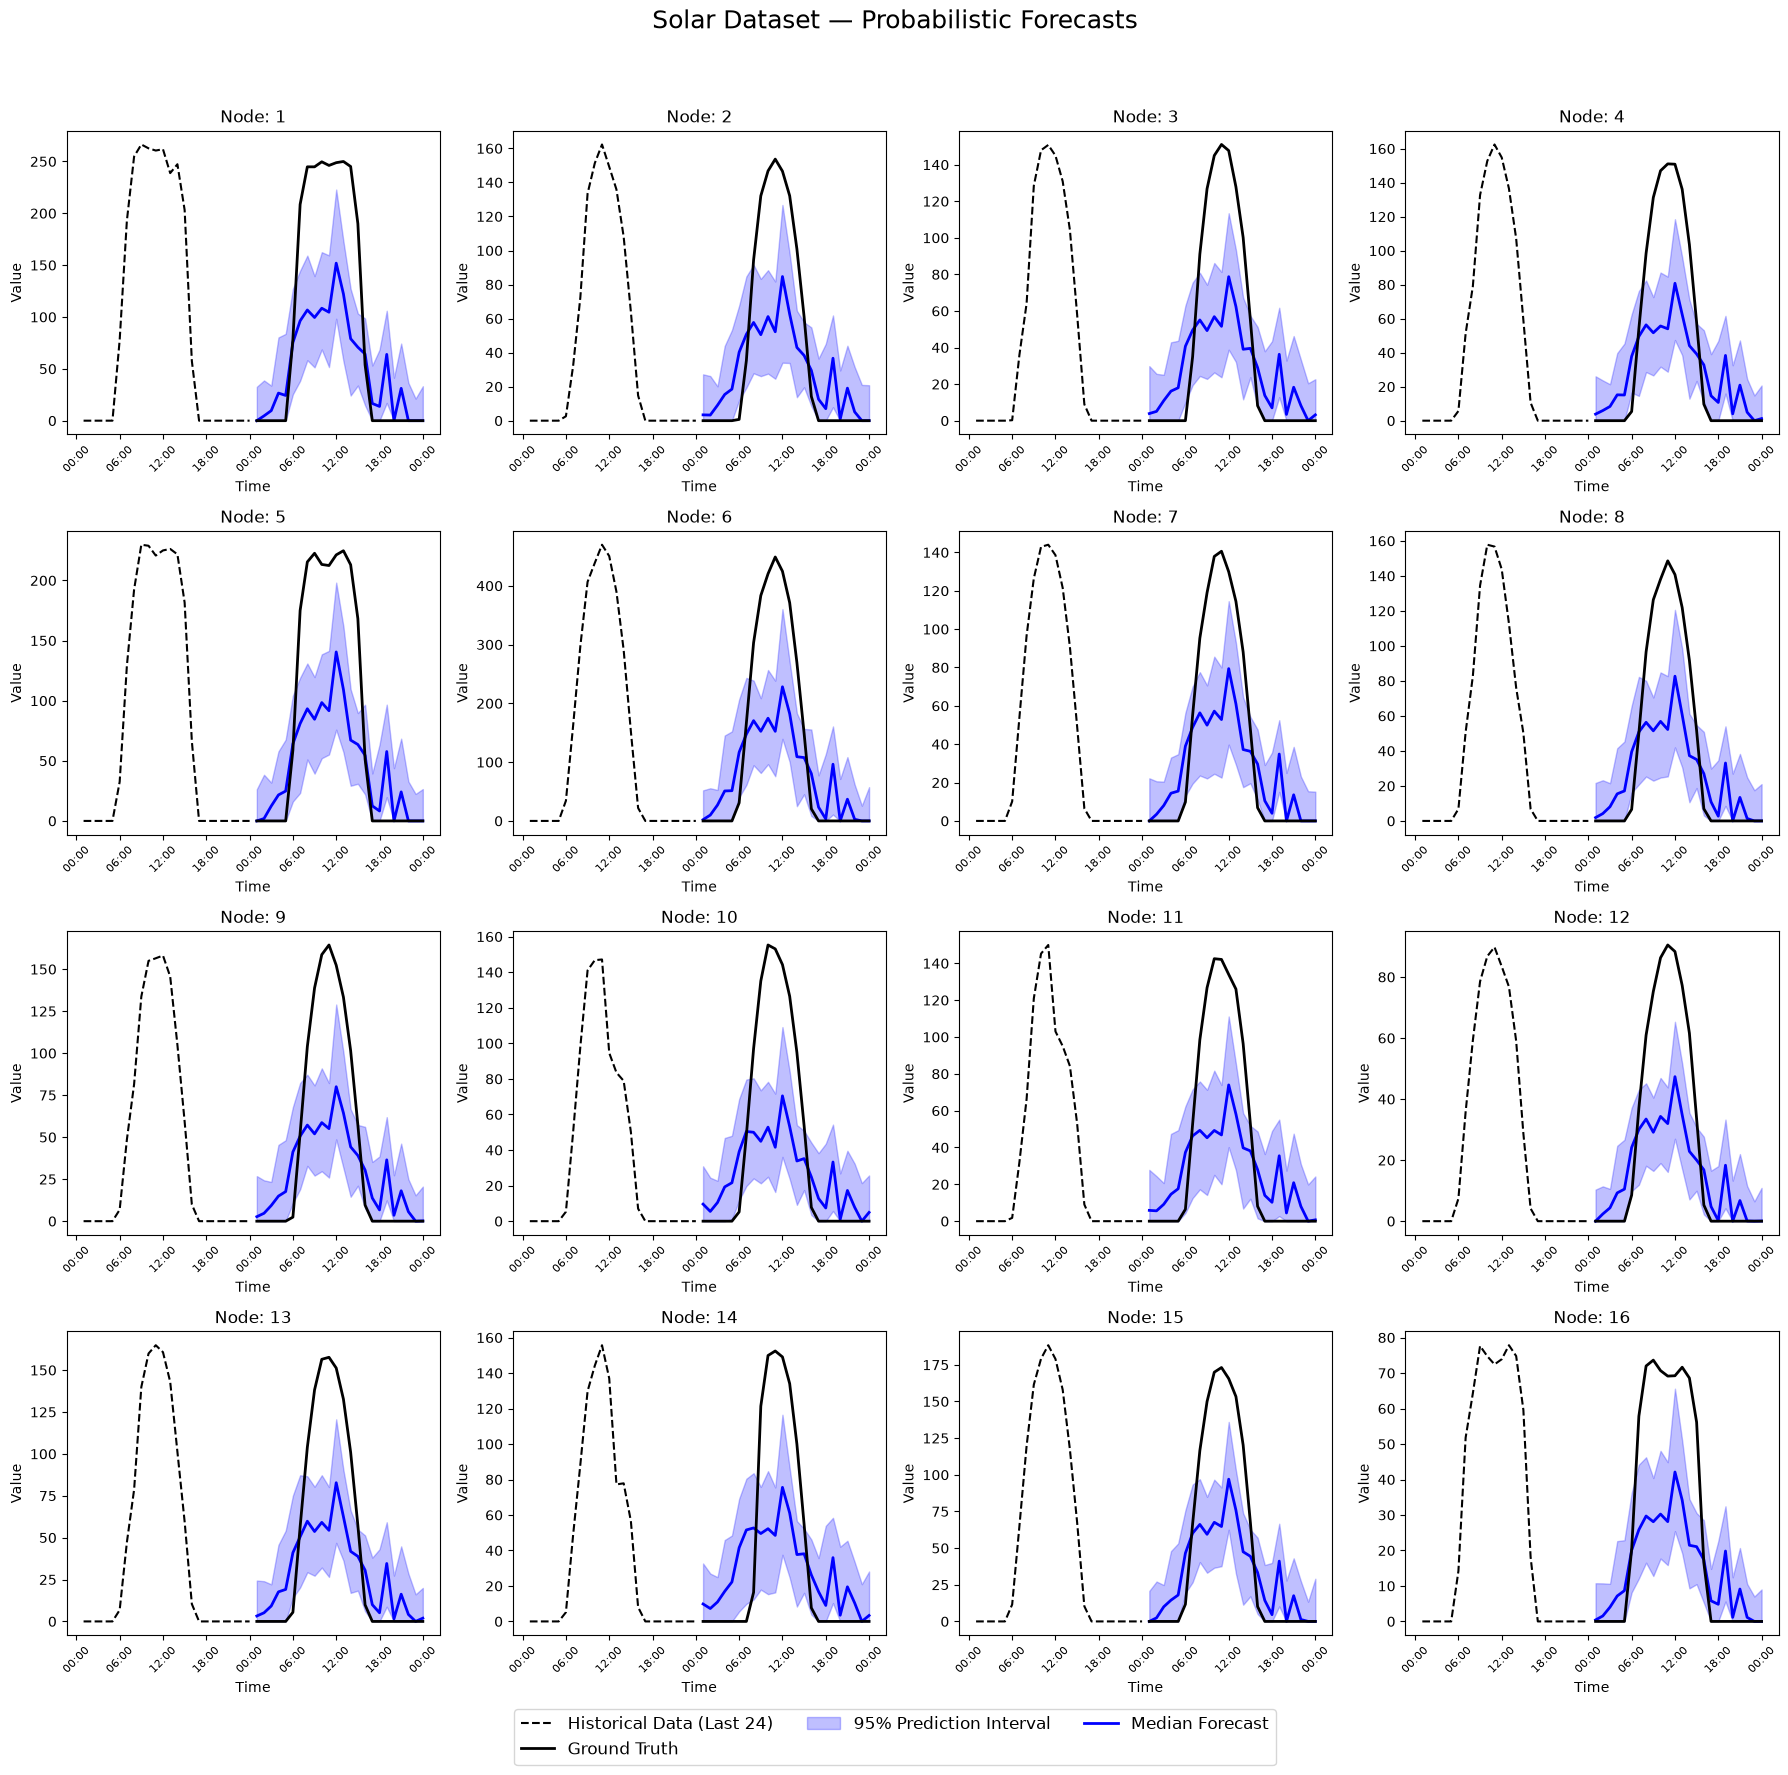

In [49]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PLOT — DARTS-STYLE PROBABILISTIC FORECAST
# ============================================================

pred_len = 24

# Same test window / data as before
historical = full_ts[-2 * pred_len : -pred_len]
actual = full_ts[-pred_len:]
forecast = forecast_unscaled

# First 16 Solar nodes
components = list(forecast.components[:16])

historical = historical[components]
actual = actual[components]
forecast = forecast[components]

print("Historical shape:", historical.all_values().shape)
print("Ground truth shape:", actual.all_values().shape)
print("Forecast shape:", forecast.all_values().shape)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

axes = axes.flatten()

fig.suptitle("Solar Dataset — Probabilistic Forecasts", fontsize=18, y=0.995)


# ============================================================
# EACH NODE
# ============================================================

for i, component in enumerate(components):

    ax = axes[i]

    # --------------------------------------------------------
    # HISTORICAL DATA — LAST 24 HOURS
    # --------------------------------------------------------

    h = historical[component]

    ax.plot(
        h.time_index,
        h.values().squeeze(),
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Historical Data (Last 24)",
    )

    # --------------------------------------------------------
    # GROUND TRUTH — NEXT 24 HOURS
    # --------------------------------------------------------

    a = actual[component]

    ax.plot(
        a.time_index,
        a.values().squeeze(),
        color="black",
        linewidth=2,
        label="Ground Truth",
        zorder=10,
    )

    # --------------------------------------------------------
    # 100 PROBABILISTIC FORECAST SAMPLES
    # --------------------------------------------------------

    samples = forecast[component].all_values().squeeze()

    if samples.ndim == 1:
        samples = samples[:, None]

    # --------------------------------------------------------
    # DARTS-STYLE QUANTILES
    # --------------------------------------------------------

    lower = np.quantile(samples, 0.025, axis=1)
    median = np.quantile(samples, 0.50, axis=1)
    upper = np.quantile(samples, 0.975, axis=1)

    forecast_times = forecast[component].time_index

    # --------------------------------------------------------
    # 95% PREDICTION INTERVAL
    # --------------------------------------------------------

    ax.fill_between(
        forecast_times,
        lower,
        upper,
        color="blue",
        alpha=0.25,
        label="95% Prediction Interval",
        zorder=1,
    )

    # --------------------------------------------------------
    # MEDIAN FORECAST
    # --------------------------------------------------------

    ax.plot(
        forecast_times,
        median,
        color="blue",
        linewidth=2,
        label="Median Forecast",
        zorder=4,
    )

    # --------------------------------------------------------
    # FORECAST START
    # --------------------------------------------------------

   

    # --------------------------------------------------------
    # FORMATTING
    # --------------------------------------------------------

    ax.set_title(f"Node: {i + 1}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")

    # Clean x-axis timestamps (Fixed Indentation)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)

    ax.grid(False)

    # Remove subplot legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()


# ============================================================
# SINGLE LEGEND
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    fontsize="large",
    bbox_to_anchor=(0.5, 0.015),
)


# ============================================================
# LAYOUT + SAVE
# ============================================================

plt.tight_layout(rect=[0, 0.05, 1, 0.97])

plt.savefig(
    "Solar_NF_Engression_Forecasts.pdf", format="pdf", bbox_inches="tight"
)

plt.show()

In [50]:
print("=" * 70)
print("TIME ALIGNMENT CHECK")
print("=" * 70)

print("\nHistorical:")
print(historical.start_time(), "->", historical.end_time())

print("\nGround truth:")
print(actual.start_time(), "->", actual.end_time())

print("\nForecast:")
print(forecast.start_time(), "->", forecast.end_time())

print("\nExpected forecast start:")
print(actual.end_time())

print("\nForecast first 5 timestamps:")
print(forecast.time_index[:5])

print("\nGround truth last 5 timestamps:")
print(actual.time_index[-5:])

print("\nForecast first timestamp == actual next timestamp?")
print(
    forecast.start_time()
    == actual.end_time() + (actual.time_index[1] - actual.time_index[0])
)

print("\nTime frequency:")
print("Actual:", actual.time_index.freq)
print("Forecast:", forecast.time_index.freq)

TIME ALIGNMENT CHECK

Historical:
2006-10-23 01:00:00 -> 2006-10-24 00:00:00

Ground truth:
2006-10-24 01:00:00 -> 2006-10-25 00:00:00

Forecast:
2006-10-24 01:00:00 -> 2006-10-25 00:00:00

Expected forecast start:
2006-10-25 00:00:00

Forecast first 5 timestamps:
DatetimeIndex(['2006-10-24 01:00:00', '2006-10-24 02:00:00',
               '2006-10-24 03:00:00', '2006-10-24 04:00:00',
               '2006-10-24 05:00:00'],
              dtype='datetime64[ns]', freq='h')

Ground truth last 5 timestamps:
DatetimeIndex(['2006-10-24 20:00:00', '2006-10-24 21:00:00',
               '2006-10-24 22:00:00', '2006-10-24 23:00:00',
               '2006-10-25 00:00:00'],
              dtype='datetime64[ns]', freq='h')

Forecast first timestamp == actual next timestamp?
False

Time frequency:
Actual: <Hour>
Forecast: <Hour>


In [51]:
# Cell 26: Define formula for Continuous Ranked Probability Score (CRPS).
# Order of execution: 26
# --------------------------------------------------
# ============================================================
# CRPS
# SAME FORMULATION USED IN THE EXISTING EVALUATION
# ============================================================

def crps(
    preds,
    targets,
    quantiles=(np.arange(20) / 20.0)[1:]
):
    """
    preds:
        (B, N, T, D)

    B = test windows
    N = probabilistic samples
    T = forecast horizon
    D = Solar nodes

    targets:
        (B, T, D)
    """

    x = np.quantile(
        preds,
        quantiles,
        axis=1,
        method="nearest"
    )

    quantiles_expanded = np.expand_dims(
        quantiles,
        axis=list(range(1, len(preds.shape)))
    )

    loss = 2 * np.sum(
        np.abs(
            (x - targets)
            * (
                (targets <= x)
                - quantiles_expanded
            )
        ),
        axis=2
    )

    return (
        loss.mean()
        / np.abs(targets).sum(axis=1).mean()
    )


def crps_sum_like_theirs(
    preds,
    targets,
    quantiles=(np.arange(20) / 20.0)[1:]
):
    """
    Compute CRPS on the aggregate Solar target
    by summing across all 137 nodes first.
    """

    preds_sum = preds.sum(axis=-1)
    targets_sum = targets.sum(axis=-1)

    return crps(
        preds_sum,
        targets_sum,
        quantiles=quantiles
    )

In [52]:
# Cell 27: Prepare past history and future ground truth for standard Test Window 5.
# Order of execution: 27
# --------------------------------------------------
# ============================================================
# CRPS ACROSS ALL 7 SOLAR TEST WINDOWS
# ============================================================

def get_crps(
    model,
    test_windows,
    y_scaler,
    pred_len=24,
    num_samples=100,
    seed=42,
):
    """
    Evaluate probabilistic CRPS across all 7 Solar test windows.
    """

    all_forecasts = []
    all_targets = []

    for i, window_df in enumerate(test_windows):

        print(
            f"Evaluating test window "
            f"{i + 1}/{len(test_windows)}..."
        )

        full_ts = TimeSeries.from_dataframe(
            window_df
        ).astype(np.float32)

        full_sc = y_scaler.transform(
            full_ts
        ).astype(np.float32)

        past_true_sc = full_sc[:-pred_len]

        gt_future = full_ts[-pred_len:]

        # ----------------------------------------------------
        # Probabilistic prediction
        # ----------------------------------------------------

        fc_sc = model.predict(
            n=pred_len,
            series=past_true_sc,
            num_samples=num_samples,
            verbose=False,
            random_state=seed,
        )

        # ----------------------------------------------------
        # Inverse scale
        # ----------------------------------------------------

        fc = y_scaler.inverse_transform(fc_sc)

        # Solar cannot be negative
        fc = fc.with_values(
            np.clip(
                fc.all_values(),
                a_min=0,
                a_max=None
            )
        )

        assert fc.time_index.equals(
            gt_future.time_index
        ), f"Forecast index mismatch in window {i}"

        all_forecasts.append(
            fc.all_values(copy=False)
        )

        all_targets.append(
            gt_future.all_values(copy=False)
        )

    # --------------------------------------------------------
    # Shapes
    #
    # forecasts:
    #   (B, T, D, N)
    #
    # CRPS expects:
    #   (B, N, T, D)
    # --------------------------------------------------------

    stacked_forecasts = np.stack(
        all_forecasts,
        axis=0
    )

    preds_reshaped = np.transpose(
        stacked_forecasts,
        (0, 3, 1, 2)
    )

    stacked_targets = np.stack(
        all_targets,
        axis=0
    )

    targets_reshaped = np.squeeze(
        stacked_targets,
        axis=-1
    )

    return crps_sum_like_theirs(
        preds_reshaped,
        targets_reshaped
    )

In [53]:
# Cell 28: Compute the final CRPS score across all 7 Solar test windows.
# Order of execution: 28
# --------------------------------------------------
# ============================================================
# CRPS — ALL 7 TEST WINDOWS
# ============================================================

start = time.time()

crps_score = get_crps(
    model=model,
    test_windows=test_windows,
    y_scaler=y_scaler,
    pred_len=OUTPUT_CHUNK_LENGTH,
    num_samples=NUM_SAMPLES_PRED,
    seed=SEED,
)

inference_time = time.time() - start

print("CRPS:", crps_score)
print(
    f"Inference time: {inference_time:.2f} seconds"
)

Evaluating test window 1/7...
Evaluating test window 2/7...
Evaluating test window 3/7...
Evaluating test window 4/7...
Evaluating test window 5/7...
Evaluating test window 6/7...
Evaluating test window 7/7...
CRPS: 0.8420673338430084
Inference time: 0.87 seconds


In [ ]:
import numpy as np
import pandas as pd
from darts.metrics import mae, rmse, mape, mase, smape, mse
import time

all_metrics = []

for i, window_df in enumerate(test_windows):
    # 1. Prepare Data
    full_ts = TimeSeries.from_dataframe(window_df).astype(np.float32)
    full_sc = y_scaler.transform(full_ts).astype(np.float32)
    
    past_true_sc = full_sc[:-OUTPUT_CHUNK_LENGTH]
    gt_future = full_ts[-OUTPUT_CHUNK_LENGTH:]
    
    # 2. Predict Probabilistically
    start_time = time.time()
    fc_sc = model.predict(
        n=OUTPUT_CHUNK_LENGTH,
        series=past_true_sc,
        num_samples=NUM_SAMPLES_PRED,
        verbose=False,
    )
    inference_time = time.time() - start_time
    
    # 3. Inverse scale and clip
    fc = y_scaler.inverse_transform(fc_sc)
    fc = fc.with_values(np.clip(fc.all_values(), a_min=0, a_max=None))
    
    # 4. Extract Point Forecast (Median)
    median_fc = fc.quantile(0.5)
    
       # 5. Compute Metrics for this window
    window_metrics = {
        "MAE": mae(gt_future, median_fc),
        "RMSE": rmse(gt_future, median_fc),
        # "MAPE": mape(gt_future, median_fc),  <-- Remove or comment out this line
        "MSE": mse(gt_future, median_fc),
        "sMAPE": smape(gt_future, median_fc),
        "Inference Time": inference_time,
    }

    
    # If you have the training series available, you can compute MASE:
    # window_metrics["MASE"] = mase(gt_future, median_fc, insample=train_ts)
    
    all_metrics.append(window_metrics)

# 6. Aggregate into a tabular DataFrame
metrics_df = pd.DataFrame(all_metrics).mean().to_frame("Value")
print("\n=== FINAL EVALUATION METRICS ===")
print(metrics_df)



=== FINAL EVALUATION METRICS ===
                      Value
MAE               27.783310
RMSE              36.473881
MSE             1749.281372
sMAPE            137.300064
Inference Time     0.107114


In [ ]:
# Cell 30: Compile and display final model parameters, evaluation scores, and runtimes in a summary table.
# Order of execution: 30
# --------------------------------------------------
# ============================================================
# FINAL RESULTS
# ============================================================

results = pd.Series({
    "Model": "EnPatchTST + Engression",
    "Training epochs (chosen)": TRAINING_EPOCHS,
    "Estimated steps/epoch": steps_per_epoch,
    "max_steps": MAX_STEPS,
    "Batch size": BATCH_SIZE,
    "Training samples": NUM_SAMPLES_TRAIN,
    "Prediction samples": NUM_SAMPLES_PRED,
    "Input length": INPUT_CHUNK_LENGTH,
    "Forecast horizon": OUTPUT_CHUNK_LENGTH,
    "CRPS": crps_score,
    "MAE": np.mean(all_mae),
    "RMSE": np.mean(all_rmse),
    "Training time (s)": training_time,
    "Inference time (s)": inference_time,
})

results

Model                       EnPatchTST + Engression
Training epochs (chosen)                          1
Estimated steps/epoch                           932
max_steps                                       109
Batch size                                       64
Training samples                                  2
Prediction samples                              100
Input length                                     24
Forecast horizon                                 24
CRPS                                       0.842067
MAE                                             NaN
RMSE                                            NaN
Training time (s)                         10.058633
Inference time (s)                         0.068668
dtype: object

: 